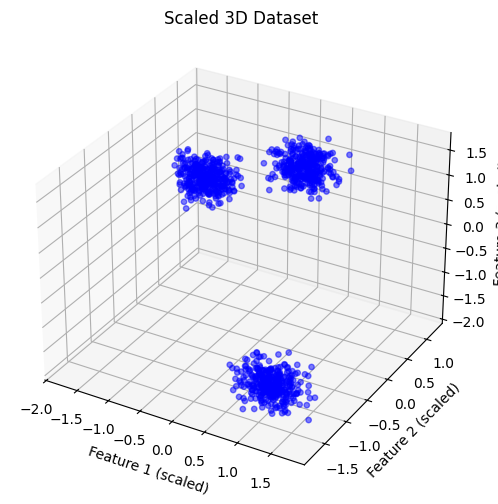

Epoch 100/1000 - loss: 248.537757
Epoch 200/1000 - loss: 23.294162
Epoch 300/1000 - loss: 11.389096
Epoch 400/1000 - loss: 8.903066
Epoch 500/1000 - loss: 7.723732
Epoch 600/1000 - loss: 6.856508
Epoch 700/1000 - loss: 6.117031
Epoch 800/1000 - loss: 5.463619
Epoch 900/1000 - loss: 4.881801
Epoch 1000/1000 - loss: 4.362897
Trained parameters: m = [ 0.55416056  8.71080081 -8.4434956 ], b = 0.999000
Sample inputs -> predictions: [-2.50863913  1.71495004 -6.89072497]


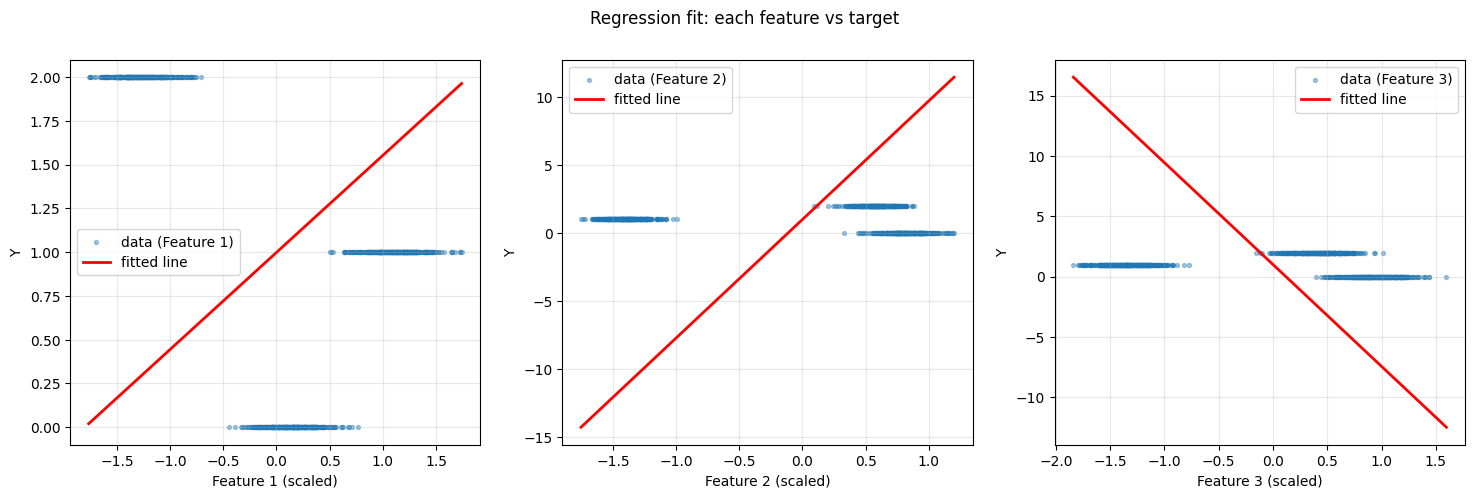

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# ========================
# 3D Dataset generation
# ========================
X, Y = make_blobs(n_samples=1000, n_features=3, random_state=42)
Y = Y.reshape(-1, 1)  # ensure Y is column vector

# ========================
# Scale features
# ========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit and transform features

# ========================
# Plot 3D scatter
# ========================
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_scaled[:,0], X_scaled[:,1], X_scaled[:,2], c='blue', alpha=0.5, s=15)
ax.set_xlabel("Feature 1 (scaled)")
ax.set_ylabel("Feature 2 (scaled)")
ax.set_zlabel("Feature 3 (scaled)")
ax.set_title("Scaled 3D Dataset")
plt.show()


# ========================
# GD Regressor for 3D
# ========================
class GDRegressor3D:
    def __init__(self, lr=0.01, epochs=1000):
        self.m = np.array([29.19, 15.0, -10.0])  # initial weights
        self.b = -100.0
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, Y):
        X = np.asarray(X)
        y = np.asarray(Y).ravel()
        n_samples = X.shape[0]

        for i in range(self.epochs):
            preds = X.dot(self.m) + self.b
            error = y - preds

            grad_m = -2.0 / n_samples * X.T.dot(error)
            grad_b = -2.0 / n_samples * np.sum(error)

            self.m -= self.lr * grad_m
            self.b -= self.lr * grad_b

            if (i+1) % (self.epochs // 10 or 1) == 0:
                loss = np.mean(error**2)
                print(f"Epoch {i+1}/{self.epochs} - loss: {loss:.6f}")

        return self.m, self.b

    def predict(self, X):
        X = np.asarray(X)
        return X.dot(self.m) + self.b


# ========================
# Training
# ========================
gd_model = GDRegressor3D(lr=0.01, epochs=1000)
gd_model.fit(X_scaled, Y)
print(f"Trained parameters: m = {gd_model.m}, b = {gd_model.b:.6f}")

# ========================
# Quick test/prediction example
# ========================
sample_X = np.array([[0.0,0.0,0.0], [1.0,2.0,-1.0], [3.5,-1.2,2.0]])
sample_X_scaled = scaler.transform(sample_X)
preds = gd_model.predict(sample_X_scaled)
print("Sample inputs -> predictions:", preds)

# =========================
# Plot features vs target (all three features)
# =========================
feature_names = ["Feature 1", "Feature 2", "Feature 3"]
fig, axes = plt.subplots(1, 3, figsize=(18,5))
x_values = X_scaled
y = Y.ravel()

for i in range(3):
    axes[i].scatter(x_values[:, i], y, s=8, alpha=0.4, label=f"data ({feature_names[i]})")
    xs = np.linspace(x_values[:, i].min(), x_values[:, i].max(), 200)
    # Line using only contribution of this feature (y ≈ m_i * x_i + b)
    ys = gd_model.m[i] * xs + gd_model.b
    axes[i].plot(xs, ys, color="red", linewidth=2, label="fitted line")
    axes[i].set_xlabel(f"{feature_names[i]} (scaled)")
    axes[i].set_ylabel("Y")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle("Regression fit: each feature vs target")
plt.show()
